### **Remote Path**

In [1]:
import sys

sys.path.append('/home/dyuser-e/NI_project_dyuser-e_2026/dynap-se1')


### **Local Path**

In [1]:
import sys
from pathlib import Path

dynapse_path = Path.home() / "NI_project" / "dynap-se1"
sys.path.append(str(dynapse_path))


### **Imports**

In [2]:

import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1

import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator

import params
from params import set_params

import time
from IPython.display import Image

import netgen as n


In [13]:
from tools.spikegen_tools import generate_regular_rate_spiketrain


In [ ]:
import samna
import samna.dynapse1 as dyn1

# append the root folder to import from the repository
import sys
sys.path.append('..')

# essential constants for DYNAP-SE1
from dynapse1constants import *

# main DYNAP-SE1 toolkit
import dynapse1utils as ut

# Network Generator helper class
import netgen as n
from netgen import Neuron

# Other standard utilities
import time
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

### **Remote Connection**

In [ ]:
# get index for board (DONT USE TO CONNECT)

model, _ = ut.open_dynapse1(gui=False, select_device=True)


[0]:  Bus 1 Device 64 Dynapse1DevKit serial_number 00000026
[1]:  Bus 1 Device 81 Dynapse1DevKit serial_number 00000000
[2]:  Bus 1 Device 80 Dynapse1DevKit serial_number 00000033
[3]:  Bus 1 Device 95 Dynapse1DevKit serial_number 00000001
[4]:  Bus 1 Device 94 Dynapse1DevKit serial_number 00000007
[5]:  Bus 1 Device 93 Dynapse1DevKit serial_number 00000020


In [ ]:
# Connecto to board with index
model = ut.open_specific_device_in_sequence(3)

### **Local Connection**

In [3]:
model, _ = ut.open_dynapse1()

[0]:  Bus 1 Device 4 Dynapse1DevKit serial_number 00000001
0 Dynapse1Wrapper created! libcaer init...
Selected device: 00000001
Sender port: tcp://0.0.0.0:44875
Receiver port: tcp://0.0.0.0:42311
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


In [27]:
# create triplets of indices of neurons to monitor
chip_id=1
core_id=0

neurons_ids = np.arange(0, 10)

neurons_ids_triplets = [(chip_id, core_id, n_id) for n_id in neurons_ids]
event_graph, filter_node, sink_node = ut.create_neuron_select_graph(model, neurons_ids_triplets)

event_graph.start()

True

### **Parameter Settings**

In [23]:
# ut.set_neuron_dc(model, chip_id, core_id, 0, 'index')

# set the AMPA synapse parameters - gain, weight and decay.
# ut.set_ampa_gain(   model, chip_id, core_id, 1800, 'index')         # "NPDPIE_THR_F_P"
ut.set_ampa_weight( model, chip_id, core_id, 1700, 'index')         # "PS_WEIGHT_EXC_F_N"
ut.set_ampa_tau(    model, chip_id, core_id, 120, 'index')          # "NPDPIE_TAU_F_P"

# set the NMDA synapse parameters - gain, weight and decay.
# ut.set_nmda_gain(   model, chip_id, core_id, 1800, 'index')         # "NPDPIE_THR_S_P"
ut.set_nmda_weight( model, chip_id, core_id, 1700, 'index')         # "PS_WEIGHT_EXC_S_N"
ut.set_nmda_tau(    model, chip_id, core_id, 120, 'index')          # "NPDPIE_TAU_S_P"

# what is set_nmda_gain() ? - makes input noisy, transistor level
# what is set_nmda_enable() ? - enables Ca circuits? if disabled, same as ampa


### **Activate Pop**

In [28]:
# re-run this cell to try recording from different neurons with various parameters

recording_length_s = 4 # seconds

sink_node.get_events() # "reset", simply empties the filter

time.sleep(recording_length_s) # physically wait for the set amount of time

events = sink_node.get_events() # fetch any freshly recorded events

print("Number of recorded events:", len(events))

avg_firing_rate = len(events)/(len(neurons_ids)*recording_length_s) # sum events together and divide by the number of neurons and the recording length
                                                                    # to get the average firing rate in Hz
print(f"Average firing rate: {avg_firing_rate} Hz")


Number of recorded events: 543
Average firing rate: 13.575 Hz


Text(0, 0.5, 'neuron ID ')

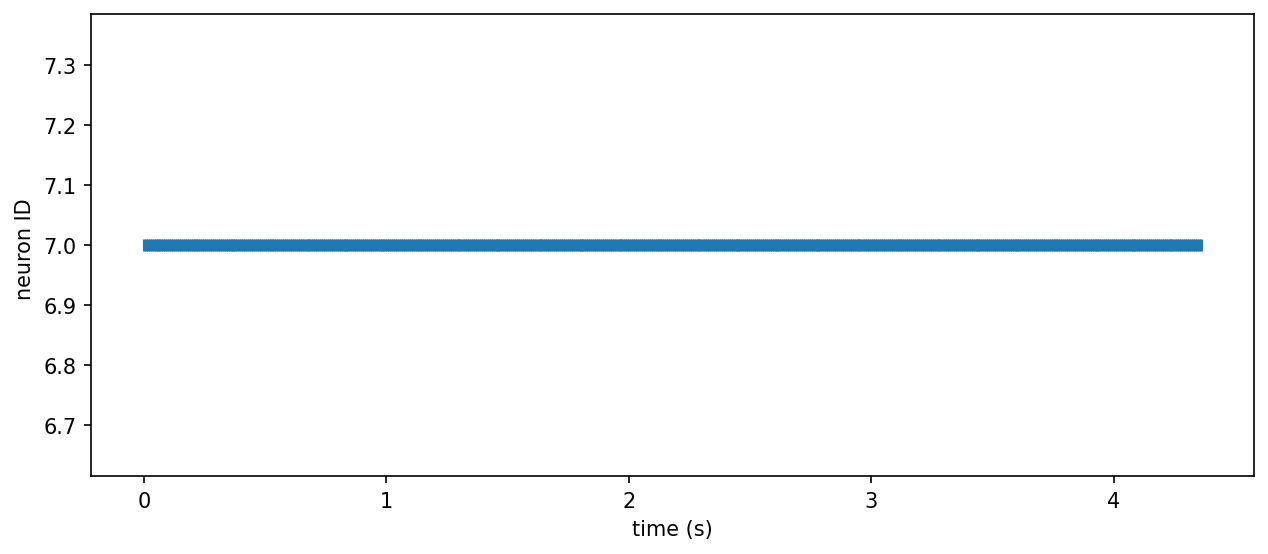

In [29]:
event_ids = np.array([evt.neuron_id for evt in events])
timestamps_us = np.array([evt.timestamp for evt in events])
timestamps_us[:]-=timestamps_us[0]
timestamps_s = timestamps_us*1e-06

plt.figure(figsize=(10,4), dpi=150)
plt.scatter(timestamps_s, event_ids, marker='|')
plt.xlabel("time (s)")
plt.ylabel("neuron ID ")


Text(0, 0.5, 'activity, hz')

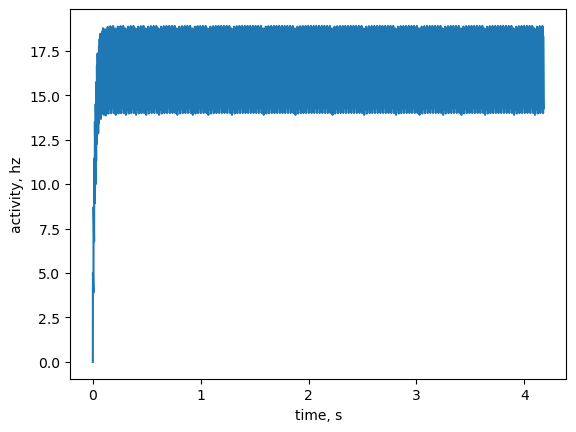

In [12]:
from tools.spikegen_tools import get_instantaneous_activity

#get activity for all neurons together using the merges spiketrain
activity_hz, activity_x = get_instantaneous_activity(timestamps_s, activity_dt_s=0.001, exp_tc_s=0.02)

#normalize the activity measurement by the number of neurons
num_neurons = len(neurons_ids)
plt.plot(activity_x, activity_hz/num_neurons)
plt.xlabel("time, s")
plt.ylabel("activity, hz")

### **Initialize Spike Generator**

Text(0, 0.5, 'spikegen')

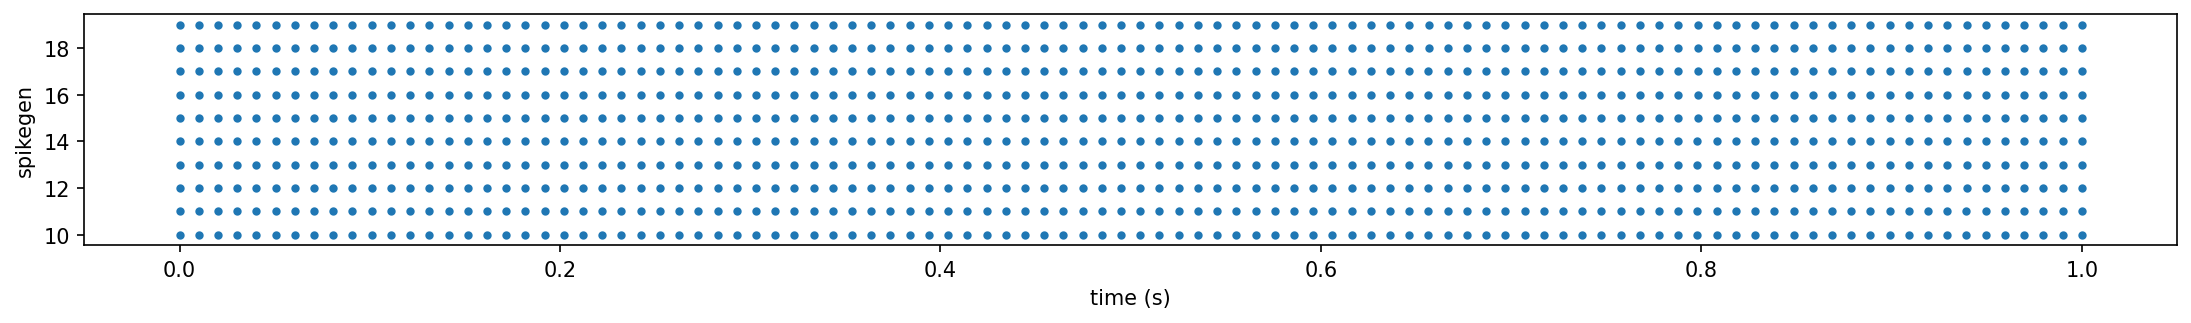

In [16]:
# prepare the spike train that the spike generators will fire

# in our case it will be a sequence of spikes at a fixed rate:
spikegen_regular_rate = 100 #Hz

rates_vector = (spikegen_regular_rate*np.ones(len(neurons_ids))).astype(int)


# generate a spiketrain
fpga_spiketrain = generate_regular_rate_spiketrain(rates_vector, neurons_ids)


# plot the prepared spiketrain to verify it is correct
plt.figure(figsize=(18,2), dpi=150)
plt.plot(fpga_spiketrain[:,0], fpga_spiketrain[:,1], '.')
plt.xlabel("time (s)")
plt.ylabel("spikegen")

In [17]:
fpga_spike_gen = model.get_fpga_spike_gen()
target_chip = chip_id # should be the same where _physical_neurons are located
fpga_spike_gen.stop()

ut.set_fpga_spike_gen(fpga_spike_gen,
                      spike_times=fpga_spiketrain[:,0],
                      indices=fpga_spiketrain[:,1].astype(int),
                      target_chips=[target_chip]*len(fpga_spiketrain),
                      isi_base=900,
                      repeat_mode=True)

# start the playback of the uploaded spike train
fpga_spike_gen.start()

FpgaSpikeGen already off!


### **FF Curve Measuremnt**

In [18]:
# Example F-F curve measurement
recording_length_s = 1

rate_min = 10 #Hz
rate_max = 400 #Hz
rate_step = 10 #Hz
recorded_rates = []

for rate in np.arange(rate_min, rate_max, rate_step):
    
    rates_vector = (rate*np.ones(len(neurons_ids))).astype(int)
    
    # prepare the spiketrain
    fpga_spiketrain = generate_regular_rate_spiketrain(rates_vector, neurons_ids)
    
    # stop the spikegen while it is being reset
    fpga_spike_gen.stop()
    ut.set_fpga_spike_gen(fpga_spike_gen,
                      spike_times=fpga_spiketrain[:,0],
                      indices=fpga_spiketrain[:,1].astype(int),
                      target_chips=[target_chip]*len(fpga_spiketrain),
                      isi_base=900,
                      repeat_mode=True)
    
    # start the spikegen with the new spiketrain
    fpga_spike_gen.start()
    
    # record and sort events
    sink_node.get_events() # "reset", simply empties the filter
    time.sleep(recording_length_s) # physically wait for the set amount of time
    events = sink_node.get_events()
    
    avg_firing_rate = len(events)/(len(neurons_ids)*recording_length_s)
    print(f"Input rate: {rate} Hz")
    print(f"Average firing rate: {avg_firing_rate} Hz")
    
    rates = dict.fromkeys(neurons_ids, 0)
    if len(events) > 0:
        for evt in events:
            rates[evt.neuron_id]+=1
        # convert event counts to individual rates by dividing them
        # by the time interval
        for n_id, evt_count in rates.items():
            rates[n_id]=evt_count/recording_length_s
            
    recorded_rates.append(rates)
    

VariableIsiMode already 1
RepeatMode already 1
Input rate: 10 Hz
Average firing rate: 17.0 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 20 Hz
Average firing rate: 16.8 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 30 Hz
Average firing rate: 16.8 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 40 Hz
Average firing rate: 16.8 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 50 Hz
Average firing rate: 16.8 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 60 Hz
Average firing rate: 16.8 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 70 Hz
Average firing rate: 16.3 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 80 Hz
Average firing rate: 16.6 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 90 Hz
Average firing rate: 16.6 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 100 Hz
Average firing rate: 16.6 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 

Text(0, 0.5, 'Mean Firing Rate')

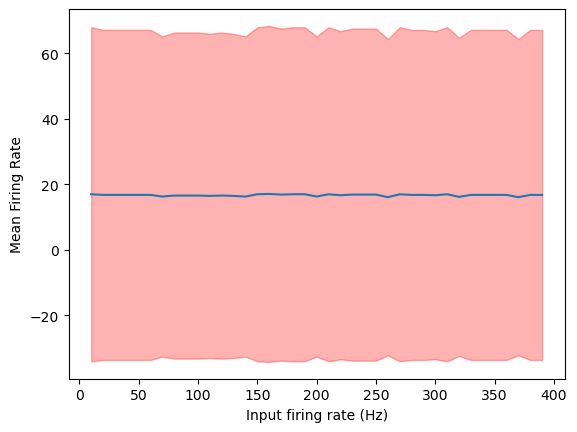

In [19]:
## store and plot the firing rate recordings

x_labels = np.arange(rate_min, rate_max, rate_step)
mean_y_labels = []
std_y_labels = []

for line, fine in zip(recorded_rates, x_labels):
    rates = np.fromiter(line.values(), dtype=float)
    #print(line.values())
    mean_rate = rates.mean()
    std_rate = rates.std()
    mean_y_labels.append(mean_rate)
    std_y_labels.append(std_rate)
    
plt.figure()
plt.plot(x_labels, mean_y_labels)
plt.fill_between(x_labels,np.array(mean_y_labels)- np.array(std_y_labels), np.array(mean_y_labels) + np.array(std_y_labels), alpha = 0.3, color = 'red')
plt.xlabel('Input firing rate (Hz)')
plt.ylabel('Mean Firing Rate')

### **Spike Adaptation Measuremtn**

In [30]:
# Enable the adaptation circuit
ut.set_adaptation_enable(model, chip_id, core_id, 1716, bias_format='index')

# Set the adaptation parameters - decay, weight and gain
ut.set_neuron_adaptation_tau(model, chip_id, core_id, 987, bias_format='index')
ut.set_neuron_adaptation_weight(model, chip_id, core_id, 1666, bias_format='index')
ut.set_neuron_adaptation_gain(model, chip_id, core_id, 1037, bias_format='index')

In [31]:
rate = 300 #hz

rates_vector = (rate*np.ones(len(neurons_ids))).astype(int)
fpga_spiketrain = generate_regular_rate_spiketrain(rates_vector, neurons_ids)

# stop the spikegen while it is being reset
fpga_spike_gen.stop()
ut.set_fpga_spike_gen(fpga_spike_gen,
                  spike_times=fpga_spiketrain[:,0],
                  indices=fpga_spiketrain[:,1].astype(int),
                  target_chips=[target_chip]*len(fpga_spiketrain),
                  isi_base=900,
                  repeat_mode=False)


VariableIsiMode already 1


Text(0, 0.5, 'neuron ID ')

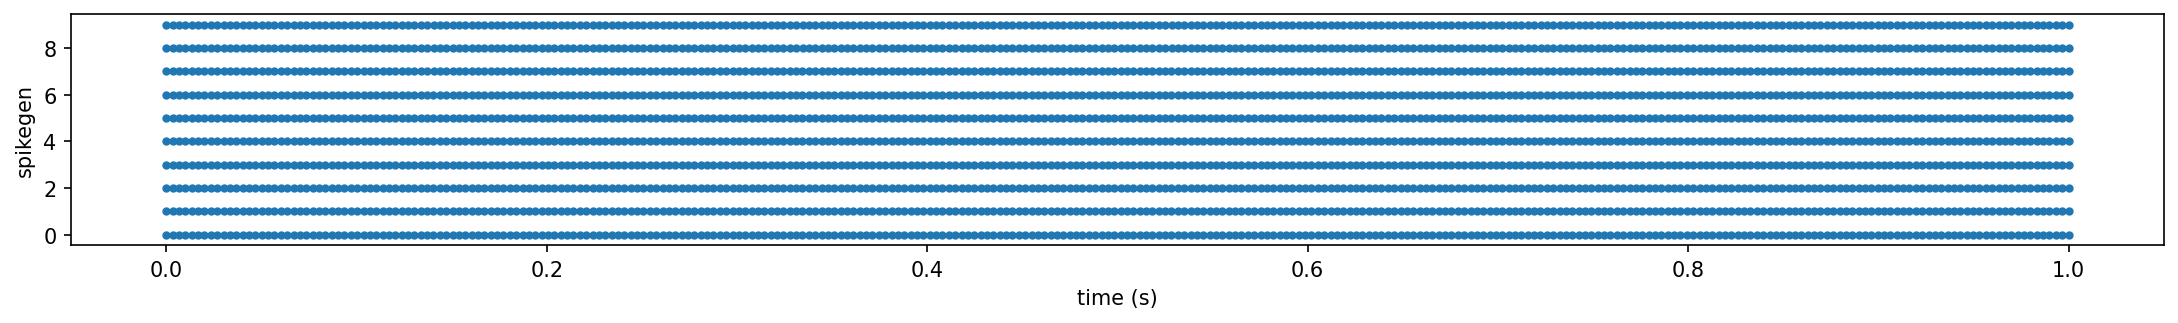

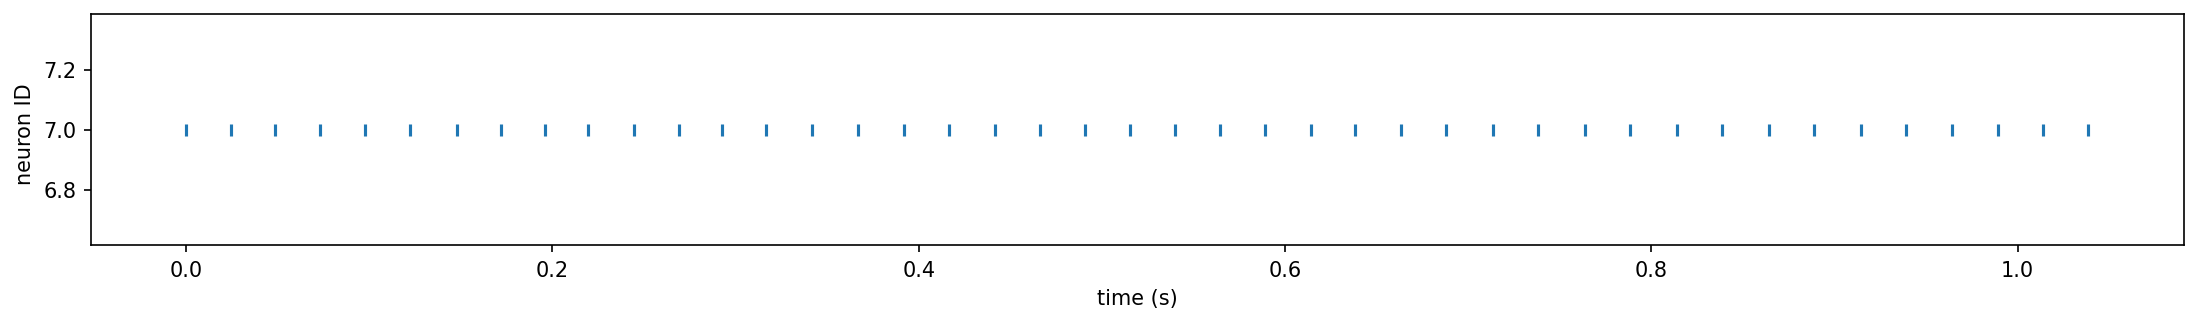

In [32]:
pre_stim_time=0.0 #s
stim_time=1 #s
post_stim_time=0 #s

#ut.set_neuron_adaptation_tau(model, chip_id, core_id, (4, 110))
#ut.set_neuron_adaptation_weight(model, chip_id, core_id, (7, 110))
#ut.set_neuron_adaptation_threshold(model, chip_id, core_id, (4, 150))

#reset the recording
sink_node.get_events()

#wait for any dynamics to stabilize
time.sleep(pre_stim_time)

#start the pulse
fpga_spike_gen.start()
time.sleep(stim_time)

#stop the pulse
fpga_spike_gen.stop()

# wait a bit more after the stimulus is off
time.sleep(post_stim_time)

#get_the events
events = sink_node.get_events()

# sort and plot the events
event_ids = np.array([evt.neuron_id for evt in events])
timestamps_us = np.array([evt.timestamp for evt in events])
timestamps_us[:]-=timestamps_us[0]
timestamps_s = timestamps_us*1e-06


plt.figure(figsize=(18,2), dpi=150)
plt.plot(fpga_spiketrain[:,0], fpga_spiketrain[:,1], '.')
plt.xlabel("time (s)")
plt.ylabel("spikegen")

plt.figure(figsize=(18,2), dpi=150)
plt.scatter(timestamps_s, event_ids, marker='|')
plt.xlabel("time (s)")
plt.ylabel("neuron ID ")

Text(0, 0.5, 'Activity (Hz)')

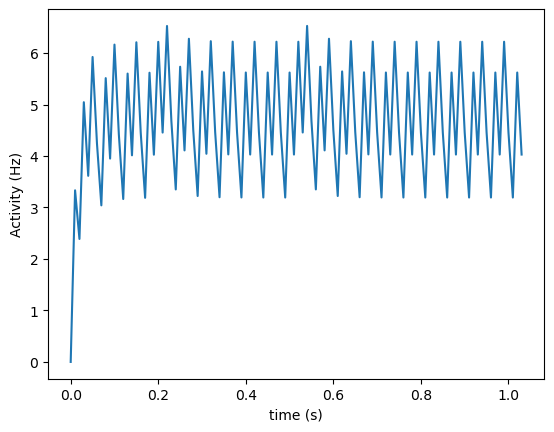

In [33]:
activity_dt = 0.01 #s
exp_time_constant = 0.03 #s

activity, activity_t = get_instantaneous_activity(timestamps_s,
                                                        activity_dt,
                                                        exp_time_constant)

activity = activity/len(neurons_ids)

plt.plot(activity_t, activity)
plt.xlabel("time (s)")
plt.ylabel("Activity (Hz)")